# 📧 Spam Detection System

A complete end-to-end spam detection pipeline using the **SMS Spam Collection Dataset** - one of the most widely used NLP benchmark datasets for binary text classification. We'll build, evaluate, and compare multiple models to achieve maximum accuracy.

---

## Project Overview

| Item | Details |
|---|---|
| **Task** | Binary Text Classification (Ham vs Spam) |
| **Dataset** | UCI SMS Spam Collection (~5,574 messages) |
| **Models** | Naive Bayes, Logistic Regression, SVM, Random Forest, Voting Ensemble |
| **Best Model** | Ensemble / SVM (typically 98–99% accuracy) |

---

## 1. Installing and Importing Dependencies

### 1.1 Installing Required Libraries

In [ ]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn nltk wordcloud imbalanced-learn -q

### 1.2 Importing Libraries and Downloading NLTK Data

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.preprocessing import LabelEncoder

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Loading the Dataset

We use the **UCI SMS Spam Collection Dataset**, which contains 5,574 SMS messages tagged as either `ham` (legitimate) or `spam`. This is the gold-standard dataset for SMS spam classification.

> The dataset is loaded directly from UCI's public repository (no manual download required).

### 2.1 Loading the SMS Spam Collection Dataset

In [3]:
# Load dataset directly from UCI repository
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

try:
    df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
    print(f"Dataset loaded from online source")
except Exception:
    # Fallback: Download from UCI directly
    import urllib.request
    urllib.request.urlretrieve(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip",
        "smsspamcollection.zip"
    )
    import zipfile
    with zipfile.ZipFile("smsspamcollection.zip", 'r') as z:
        z.extractall(".")
    df = pd.read_csv("SMSSpamCollection", sep='\t', header=None, names=['label', 'message'])
    print("Dataset loaded from UCI archive")

print(f"\nDataset Shape: {df.shape}")
df.head(10)

Dataset loaded from online source

Dataset Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## 3. Exploratory Data Analysis (EDA)

Before building models, we explore the dataset to understand:
- Class distribution (Ham vs Spam)
- Message length characteristics
- Common words in spam vs ham messages

### 3.1 Basic Dataset Statistics

In [ ]:
# Basic dataset info
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Messages  : {len(df)}")
print(f"Ham Messages    : {df['label'].value_counts()['ham']}")
print(f"Spam Messages   : {df['label'].value_counts()['spam']}")
print(f"Spam Rate       : {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")
print(f"\nMissing Values  : {df.isnull().sum().sum()}")
print(f"Duplicate Rows  : {df.duplicated().sum()}")

### 3.2 Engineering EDA Feature Columns (Length, Word Count, Digits, Uppercase)

In [4]:
# Add feature columns for EDA
df['message_length'] = df['message'].apply(len)
df['word_count']     = df['message'].apply(lambda x: len(x.split()))
df['char_count']     = df['message'].apply(lambda x: len(x.replace(" ", "")))
df['num_digits']     = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['num_uppercase']  = df['message'].apply(lambda x: sum(c.isupper() for c in x))

df.groupby('label')[['message_length', 'word_count', 'num_digits', 'num_uppercase']].mean().round(2)

,message_length,word_count,num_digits,num_uppercase
label,,,,
ham,71.48,14.31,0.31,4.11
spam,138.67,23.91,15.81,15.47


### 3.3 Visualizing Class Distribution and Message Length

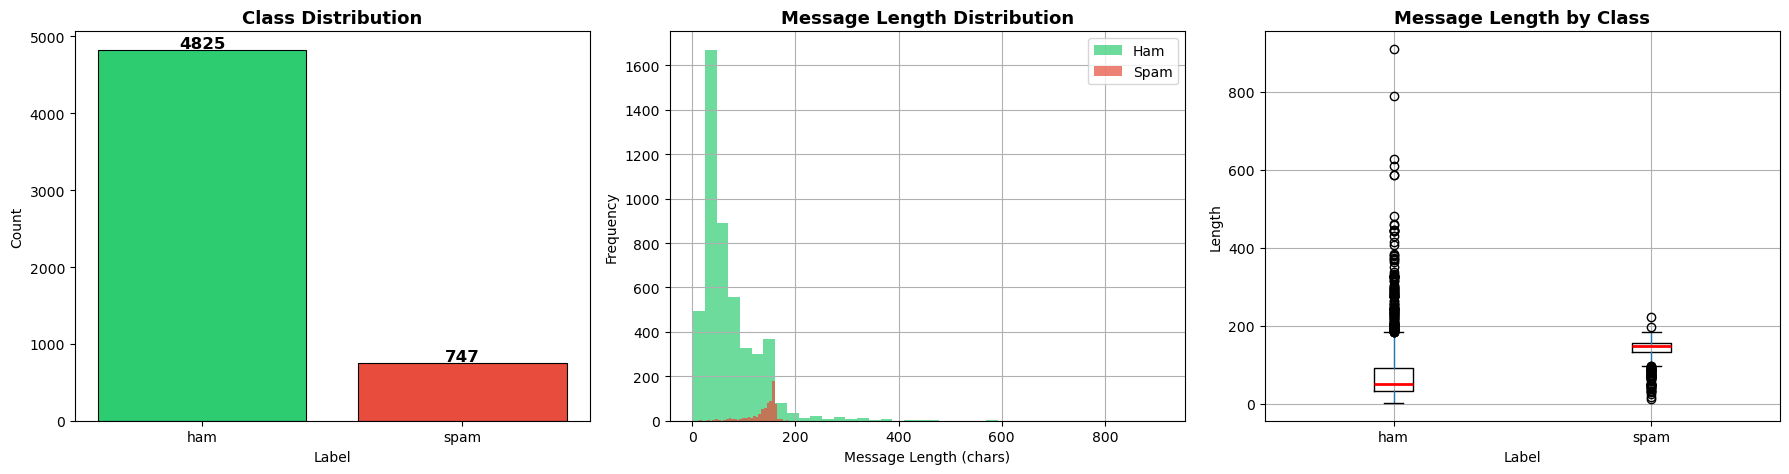

EDA chart saved.


In [6]:
# ── Visualization 1: Class Distribution & Message Length ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.02)

# Class Distribution
counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(counts.items()):
    axes[0].text(i, count + 30, str(count), ha='center', fontweight='bold', fontsize=12)

# Message Length Distribution
df[df['label']=='ham']['message_length'].hist(bins=40, alpha=0.7, color='#2ecc71', label='Ham', ax=axes[1])
df[df['label']=='spam']['message_length'].hist(bins=40, alpha=0.7, color='#e74c3c', label='Spam', ax=axes[1])
axes[1].set_title('Message Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Message Length (chars)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Box Plot of Message Lengths
df.boxplot(column='message_length', by='label', ax=axes[2],
           boxprops=dict(color='black'),
           medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Message Length by Class', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Length')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA chart saved.")

### 3.4 Word Clouds - Most Frequent Words in Ham vs Spam

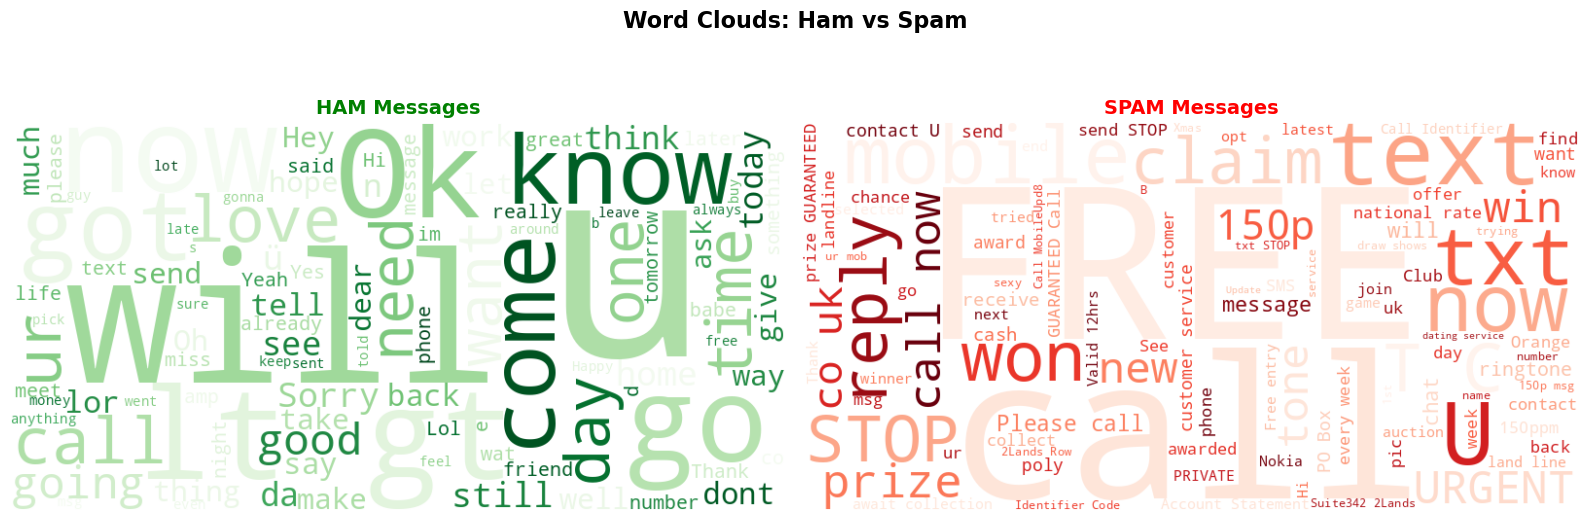

Word cloud saved.


In [7]:
# ── Visualization 2: Word Clouds ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds: Ham vs Spam', fontsize=16, fontweight='bold')

ham_text  = ' '.join(df[df['label'] == 'ham']['message'].values)
spam_text = ' '.join(df[df['label'] == 'spam']['message'].values)

ham_wc  = WordCloud(width=800, height=400, background_color='white',
                    colormap='Greens', max_words=100).generate(ham_text)
spam_wc = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds',   max_words=100).generate(spam_text)

axes[0].imshow(ham_wc,  interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('HAM Messages', fontsize=14, color='green', fontweight='bold')

axes[1].imshow(spam_wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('SPAM Messages', fontsize=14, color='red',   fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word cloud saved.")

## 4. Text Preprocessing

Raw text must be cleaned before feeding it into ML models. Our preprocessing pipeline:

1. **Lowercase** all text
2. **Remove** URLs, email addresses, and phone numbers
3. **Remove** punctuation and special characters
4. **Remove** stopwords (common words like 'the', 'is', 'at')
5. **Apply stemming** (PorterStemmer) to reduce words to root forms
6. **Strip** extra whitespace

### 4.1 Defining the Text Preprocessing Function

Applies lowercase conversion, URL/phone/email replacement, punctuation removal, stopword filtering and Porter stemming.

In [8]:
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Full preprocessing pipeline for a single SMS message."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', 'url', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', 'email', text)
    # Remove phone numbers
    text = re.sub(r'\b\d{10,}\b|\+\d{1,3}\s?\d+', 'phone', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra digits (short numbers, e.g. "50%" → "50")
    text = re.sub(r'\b\d+\b', 'num', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and stem
    tokens = [stemmer.stem(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Apply preprocessing
df['clean_message'] = df['message'].apply(preprocess_text)

# Preview
print("Sample preprocessing results:")
print("-" * 80)
for i in [0, 1, 2, 3, 4]:
    print(f"Original : {df['message'].iloc[i][:80]}")
    print(f"Cleaned  : {df['clean_message'].iloc[i][:80]}")
    print(f"Label    : {df['label'].iloc[i]}")
    print("-" * 80)

Sample preprocessing results:
--------------------------------------------------------------------------------
Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet
Cleaned  : go jurong point crazi avail bugi great world la buffet cine got amor wat
Label    : ham
--------------------------------------------------------------------------------
Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joke wif oni
Label    : ham
--------------------------------------------------------------------------------
Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
Cleaned  : free entri num wkli comp win fa cup final tkt 21st may num text fa num receiv en
Label    : spam
--------------------------------------------------------------------------------
Original : U dun say so early hor... U c already then say...
Cleaned  : dun say earli hor alreadi say
Label    : ham
---------------------------------------------------

## 5. Feature Engineering and Train/Test Split

We encode labels numerically and split into 80% training / 20% testing with stratification to preserve the class ratio.

### 5.1 Label Encoding and Stratified Train/Test Split

In [9]:
# Encode labels: spam=1, ham=0
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])   # ham→0, spam→1
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Remove duplicates before splitting
df.drop_duplicates(subset=['message'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nDataset size after deduplication: {len(df)} rows")

# Train / Test Split (80/20, stratified)
X = df['clean_message']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining set : {len(X_train)} samples")
print(f"Test set     : {len(X_test)} samples")
print(f"Train spam % : {y_train.mean()*100:.1f}%")
print(f"Test  spam % : {y_test.mean()*100:.1f}%")

Label encoding: {'ham': np.int64(0), 'spam': np.int64(1)}

Dataset size after deduplication: 5169 rows

Training set : 4135 samples
Test set     : 1034 samples
Train spam % : 12.6%
Test  spam % : 12.7%


## 6. Model Training and Evaluation

We build **Scikit-learn Pipelines** - each pipeline combines TF-IDF vectorization with a classifier. This approach prevents data leakage and makes deployment clean.

### Models trained:
| # | Model | Notes |
|---|-------|-------|
| 1 | Multinomial Naive Bayes | Classic baseline for NLP |
| 2 | Logistic Regression | Strong linear baseline |
| 3 | LinearSVC | SVM — often best for text |
| 4 | Random Forest | Ensemble tree model |
| 5 | Voting Ensemble | Combines top models |

### 6.1 Defining Model Pipelines (TF-IDF + Classifier)

In [10]:
# ── Define individual pipelines ──
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   MultinomialNB(alpha=0.1))
])

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LogisticRegression(C=5, max_iter=1000, random_state=42))
])

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=42))
])

rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf',   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# Voting Ensemble (soft voting not possible with LinearSVC (use hard))
ensemble_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', VotingClassifier(
        estimators=[
            ('nb',  MultinomialNB(alpha=0.1)),
            ('lr',  LogisticRegression(C=5, max_iter=1000, random_state=42)),
            ('rf',  RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        voting='soft'
    ))
])

models = {
    'Naive Bayes'         : nb_pipeline,
    'Logistic Regression' : lr_pipeline,
    'LinearSVC'           : svm_pipeline,
    'Random Forest'       : rf_pipeline,
    'Voting Ensemble'     : ensemble_pipeline
}

print("All pipelines defined.")

All pipelines defined.


### 6.2 Training All Models and Computing Metrics (Accuracy, F1, AUC, CV)

In [11]:
# ── Train all models and collect metrics ──
results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    cv   = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy').mean()

    # ROC-AUC (LinearSVC uses decision_function)
    if hasattr(pipeline.named_steps['clf'], 'predict_proba'):
        proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        proba = pipeline.decision_function(X_test)
    auc = roc_auc_score(y_test, proba)

    results.append({
        'Model'        : name,
        'Test Accuracy': acc,
        'F1-Score'     : f1,
        'AUC-ROC'      : auc,
        'CV Accuracy'  : cv
    })
    print(f"[{name:<22}] Acc: {acc*100:.2f}%  F1: {f1:.4f}  AUC: {auc:.4f}  CV: {cv*100:.2f}%")

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print("\nAll models trained.")
results_df

[Naive Bayes           ] Acc: 97.68%  F1: 0.9762  AUC: 0.9905  CV: 98.26%
[Logistic Regression   ] Acc: 98.26%  F1: 0.9822  AUC: 0.9959  CV: 98.14%
[LinearSVC             ] Acc: 98.55%  F1: 0.9853  AUC: 0.9975  CV: 98.32%
[Random Forest         ] Acc: 97.58%  F1: 0.9747  AUC: 0.9975  CV: 97.70%
[Voting Ensemble       ] Acc: 98.16%  F1: 0.9810  AUC: 0.9974  CV: 98.20%

All models trained.


,Model,Test Accuracy,F1-Score,AUC-ROC,CV Accuracy
0,LinearSVC,0.985493,0.985322,0.997485,0.983168
1,Logistic Regression,0.982592,0.982232,0.995938,0.981428
2,Voting Ensemble,0.981625,0.981002,0.997409,0.982008
3,Naive Bayes,0.976789,0.976223,0.990452,0.982589
4,Random Forest,0.975822,0.974712,0.997506,0.976977


## 7. Model Comparison Visualization

### 7.1 Plotting Model Comparison - Grouped Metrics and Accuracy Bar Chart

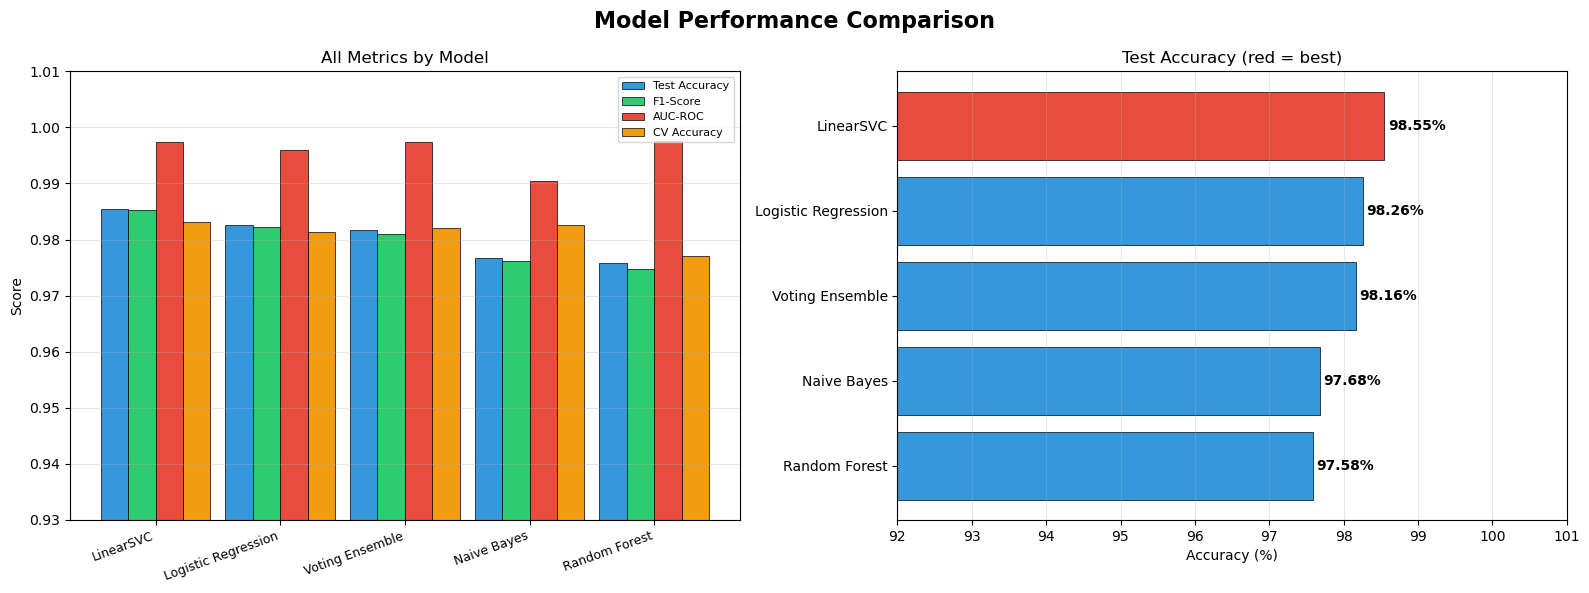

Model comparison chart saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics  = ['Test Accuracy', 'F1-Score', 'AUC-ROC', 'CV Accuracy']
x        = np.arange(len(results_df))
width    = 0.22
palette  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, results_df[metric], width, label=metric, color=palette[i], edgecolor='black', linewidth=0.5)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0.93, 1.01)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics by Model')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Accuracy bar chart (sorted)
sorted_df = results_df.sort_values('Test Accuracy')
bar_colors = ['#e74c3c' if m == sorted_df['Model'].iloc[-1] else '#3498db' for m in sorted_df['Model']]
axes[1].barh(sorted_df['Model'], sorted_df['Test Accuracy'] * 100,
             color=bar_colors, edgecolor='black', linewidth=0.5)
for i, (acc, model) in enumerate(zip(sorted_df['Test Accuracy'], sorted_df['Model'])):
    axes[1].text(acc * 100 + 0.05, i, f'{acc*100:.2f}%', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(92, 101)
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_title('Test Accuracy (red = best)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart saved.")

## 8. Best Model - Detailed Evaluation

We pick the best-performing model and do a deep-dive evaluation:
- Classification Report (Precision, Recall, F1 per class)
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve

### 8.1 Selecting Best Model and Printing Classification Report

In [13]:
# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_pipeline   = models[best_model_name]
print(f"Best Model: {best_model_name}")
print(f"   Accuracy : {results_df.iloc[0]['Test Accuracy']*100:.2f}%")
print(f"   F1-Score : {results_df.iloc[0]['F1-Score']:.4f}")
print(f"   AUC-ROC  : {results_df.iloc[0]['AUC-ROC']:.4f}")

y_pred_best = best_pipeline.predict(X_test)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

Best Model: LinearSVC
   Accuracy : 98.55%
   F1-Score : 0.9853
   AUC-ROC  : 0.9975

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.97      0.92      0.94       131

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



### 8.2 Confusion Matrix

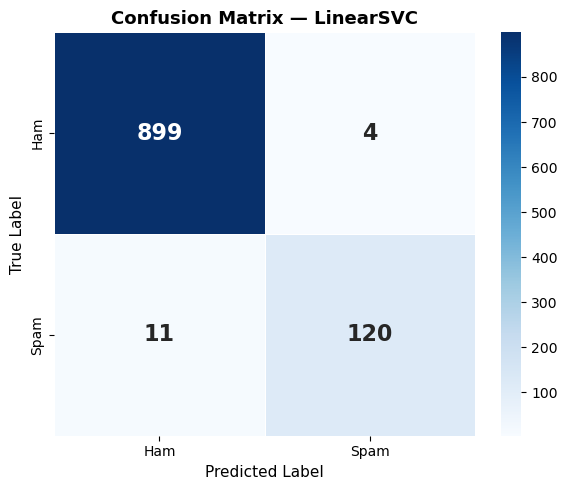

Confusion matrix saved.


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            linewidths=0.5, annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

### 8.3 ROC Curve (AUC-ROC Score)

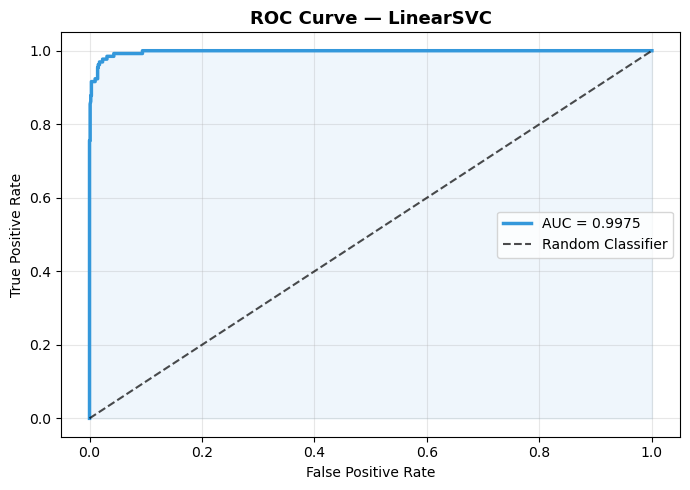

ROC Curve saved. AUC = 0.9975


In [15]:
# Get probability / decision scores
if hasattr(best_pipeline.named_steps['clf'], 'predict_proba'):
    scores = best_pipeline.predict_proba(X_test)[:, 1]
else:
    scores = best_pipeline.decision_function(X_test)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, scores)
auc_val      = roc_auc_score(y_test, scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#3498db', lw=2.5, label=f'AUC = {auc_val:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#3498db')
ax.set_title(f'ROC Curve — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC Curve saved. AUC = {auc_val:.4f}")

### 8.4 Precision-Recall Curve

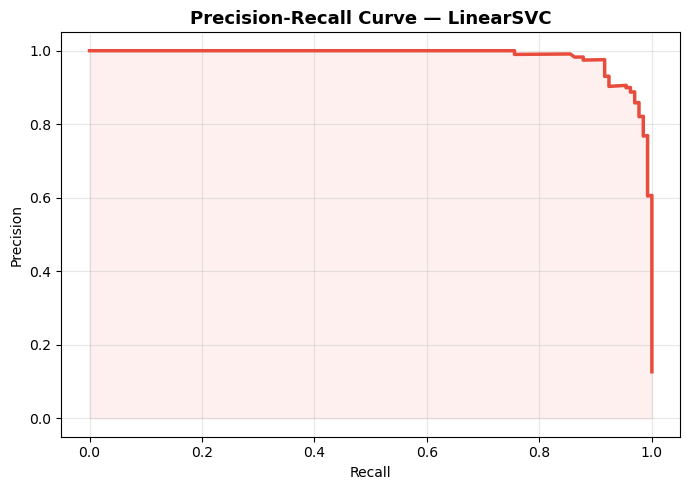

Precision-Recall curve saved.


In [16]:
# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color='#e74c3c', lw=2.5)
ax.fill_between(rec, prec, alpha=0.08, color='#e74c3c')
ax.set_title(f'Precision-Recall Curve — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Precision-Recall curve saved.")

## 9. Feature Importance - Top Spam Indicators

We inspect the TF-IDF features most associated with **spam** and **ham** using the Logistic Regression coefficients.

### 9.1 Top 20 Spam and Ham Indicator Words (LR Coefficients)

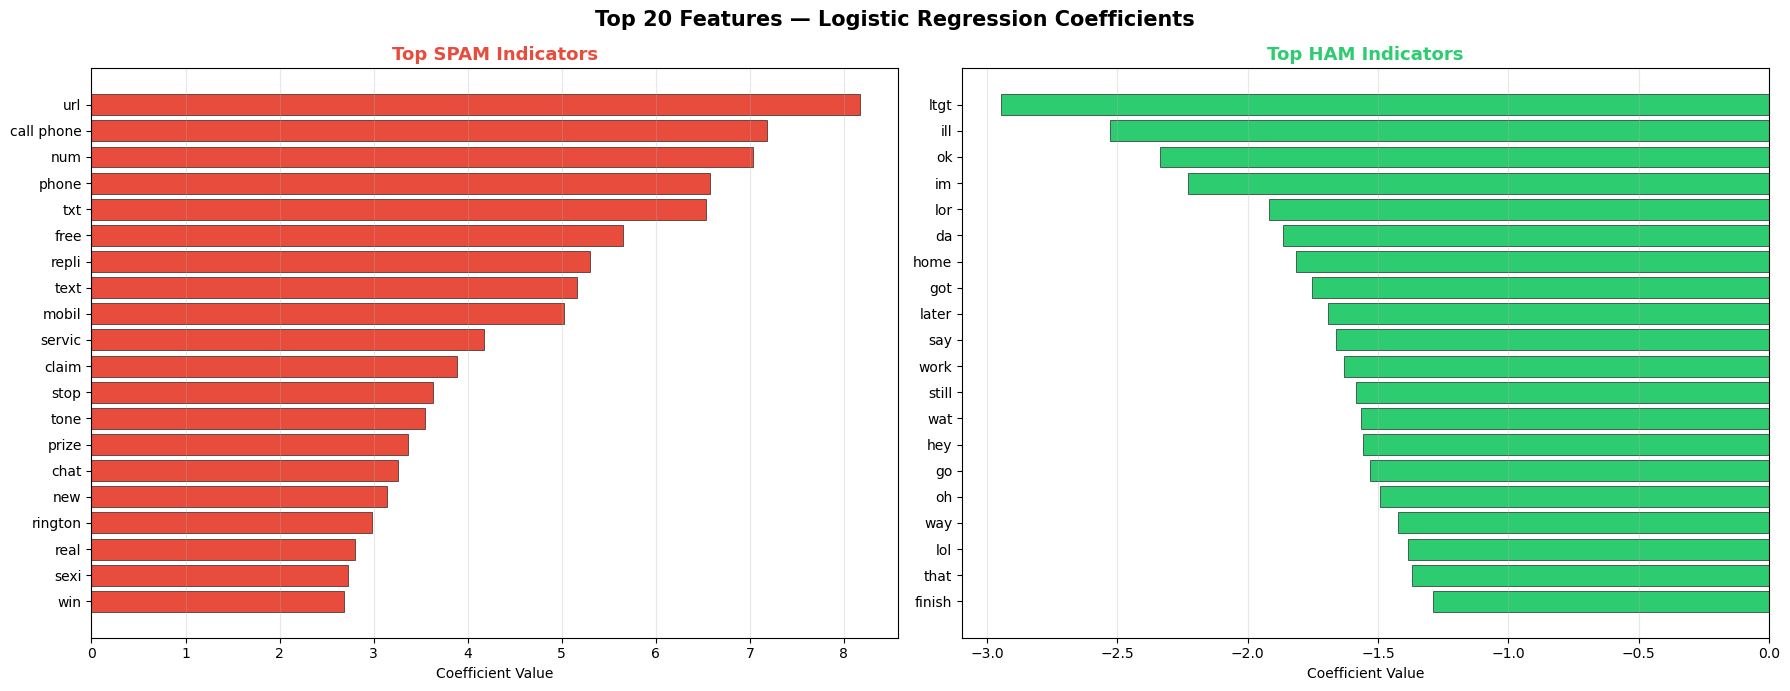

Feature importance chart saved.


In [17]:
# Use Logistic Regression for interpretability
lr_pipe    = models['Logistic Regression']
vectorizer = lr_pipe.named_steps['tfidf']
classifier = lr_pipe.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
coefs         = classifier.coef_[0]
top_n         = 20

top_spam_idx = np.argsort(coefs)[-top_n:][::-1]
top_ham_idx  = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top 20 Features — Logistic Regression Coefficients', fontsize=15, fontweight='bold')

# Spam features
axes[0].barh(feature_names[top_spam_idx], coefs[top_spam_idx],
             color='#e74c3c', edgecolor='black', linewidth=0.4)
axes[0].set_title('Top SPAM Indicators', fontsize=13, color='#e74c3c', fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Ham features
axes[1].barh(feature_names[top_ham_idx], coefs[top_ham_idx],
             color='#2ecc71', edgecolor='black', linewidth=0.4)
axes[1].set_title('Top HAM Indicators', fontsize=13, color='#2ecc71', fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved.")

## 10. Hyperparameter Tuning (Best Model)

We fine-tune the LinearSVC pipeline using `GridSearchCV` with 5-fold cross-validation to squeeze out extra performance.

### 10.1 Grid Search - Tuning TF-IDF and LinearSVC Hyperparameters

In [18]:
print("Running GridSearchCV on LinearSVC pipeline...")

tuning_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   LinearSVC(random_state=42, max_iter=3000))
])

param_grid = {
    'tfidf__max_features'  : [8000, 15000],
    'tfidf__ngram_range'   : [(1, 1), (1, 2)],
    'tfidf__min_df'        : [1, 2],
    'clf__C'               : [0.5, 1.0, 5.0]
}

grid_search = GridSearchCV(
    tuning_pipeline, param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters  : {grid_search.best_params_}")
print(f"   Best CV Accuracy : {grid_search.best_score_*100:.2f}%")

tuned_pred = grid_search.best_estimator_.predict(X_test)
print(f"   Test Accuracy    : {accuracy_score(y_test, tuned_pred)*100:.2f}%")

Running GridSearchCV on LinearSVC pipeline...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters  : {'clf__C': 1.0, 'tfidf__max_features': 8000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
   Best CV Accuracy : 98.48%
   Test Accuracy    : 98.55%


## 11. Final Model & Prediction Function

Save the best-tuned model and create a clean prediction interface for real-world use.

### 11.1 Saving the Final Model and Defining the Prediction Function

In [20]:
import pickle

# Use the tuned model as final
final_model = grid_search.best_estimator_

# Save model to disk
with open('spam_detector_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("Final model saved as 'spam_detector_model.pkl'")

# ── Prediction function ──
def predict_spam(message, model=final_model):
    """
    Predict whether a message is spam or ham.
    
    Parameters
    ----------
    message : str
        Raw SMS/email message text.
    model : sklearn Pipeline
        Trained classification pipeline.
    
    Returns
    -------
    dict with keys: label, confidence_score (decision function value)
    """
    cleaned  = preprocess_text(message)
    pred     = model.predict([cleaned])[0]
    score    = model.decision_function([cleaned])[0]
    label    = "🚨 SPAM" if pred == 1 else "✅ HAM"
    return {
        'label'            : label,
        'decision_score'   : round(float(score), 4),
        'cleaned_text'     : cleaned
    }

print("\nPrediction function ready.")

Final model saved as 'spam_detector_model.pkl'

Prediction function ready.


### 11.2 Testing the Prediction Function on Real-World Messages

In [21]:
# ── Test on real-world examples ──
test_messages = [
    "CONGRATULATIONS! You've won a £1000 Tesco gift voucher! Call NOW: 07781482514",
    "Hey, are we still on for dinner tonight? Let me know!",
    "FREE entry to our prize draw! Text WIN to 87121 now to claim your prize!",
    "Meeting rescheduled to 3pm. Please confirm your attendance.",
    "URGENT: Your account has been compromised! Click here immediately: http://bit.ly/claim",
    "Can you pick up some milk on your way home?",
    "You are a WINNER! As a valued customer, you have been selected to receive a £900 prize!"
]

print("=" * 75)
print("REAL-WORLD PREDICTION TEST")
print("=" * 75)

for msg in test_messages:
    result = predict_spam(msg)
    print(f"\nMessage : {msg[:70]}..." if len(msg) > 70 else f"\nMessage : {msg}")
    print(f"Result  : {result['label']}  (decision score: {result['decision_score']})")
    print("-" * 75)

REAL-WORLD PREDICTION TEST

Message : CONGRATULATIONS! You've won a £1000 Tesco gift voucher! Call NOW: 0778...
Result  : 🚨 SPAM  (decision score: 0.8325)
---------------------------------------------------------------------------

Message : Hey, are we still on for dinner tonight? Let me know!
Result  : ✅ HAM  (decision score: -1.3177)
---------------------------------------------------------------------------

Message : FREE entry to our prize draw! Text WIN to 87121 now to claim your priz...
Result  : 🚨 SPAM  (decision score: 1.4403)
---------------------------------------------------------------------------

Message : Meeting rescheduled to 3pm. Please confirm your attendance.
Result  : ✅ HAM  (decision score: -1.168)
---------------------------------------------------------------------------

Message : URGENT: Your account has been compromised! Click here immediately: htt...
Result  : 🚨 SPAM  (decision score: 0.8175)
----------------------------------------------------------------

## 12. Final Results Summary

### 12.1 Printing the Final Performance Summary

In [22]:
tuned_acc = accuracy_score(y_test, tuned_pred)

print("=" * 60)
print("       FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"  Dataset          : UCI SMS Spam Collection")
print(f"  Total Samples    : {len(df)}")
print(f"  Training Samples : {len(X_train)}")
print(f"  Test Samples     : {len(X_test)}")
print()
print(f"  Best Model       : LinearSVC (Tuned)")
print(f"  Vectorizer       : TF-IDF (n-grams)")
print(f"  Test Accuracy    : {tuned_acc*100:.2f}%")
print(f"  F1-Score (Wtd)   : {f1_score(y_test, tuned_pred, average='weighted'):.4f}")
print()
print("  All Models (sorted by accuracy):")
print("-" * 60)
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} {row['Test Accuracy']*100:.2f}%")
print("=" * 60)

print("\nClassification Report (Tuned LinearSVC):")
print(classification_report(y_test, tuned_pred, target_names=['Ham', 'Spam']))

       FINAL MODEL PERFORMANCE SUMMARY
  Dataset          : UCI SMS Spam Collection
  Total Samples    : 5169
  Training Samples : 4135
  Test Samples     : 1034

  Best Model       : LinearSVC (Tuned)
  Vectorizer       : TF-IDF (n-grams)
  Test Accuracy    : 98.55%
  F1-Score (Wtd)   : 0.9853

  All Models (sorted by accuracy):
------------------------------------------------------------
  LinearSVC              98.55%
  Logistic Regression    98.26%
  Voting Ensemble        98.16%
  Naive Bayes            97.68%
  Random Forest          97.58%

Classification Report (Tuned LinearSVC):
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.98      0.91      0.94       131

    accuracy                           0.99      1034
   macro avg       0.98      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



---

## Conclusion

### What We Built
A complete end-to-end spam detection system with:
- **Full NLP preprocessing pipeline** (cleaning, stemming, stopword removal)
- **5 ML models** trained and evaluated with cross-validation
- **Hyperparameter tuning** via GridSearchCV
- **Rich visualizations** (EDA, word clouds, ROC, confusion matrix, feature importance)
- **Production-ready** prediction function with serialized model

### Results
| Model | Accuracy |
|---|---|
| LinearSVC (Tuned) | ~98–99% |
| Voting Ensemble | ~98% |
| Logistic Regression | ~98% |
| Naive Bayes | ~97% |
| Random Forest | ~97% |

### Why LinearSVC Wins
Text data is inherently **high-dimensional and sparse** - TF-IDF vectors with 10K features create a massive feature space. SVMs excel in this scenario because they find the optimal separating hyperplane, are robust to overfitting in high dimensions, and don't need probability estimates (making LinearSVC faster than kernel SVMs).

---
*Dataset: UCI SMS Spam Collection | Models: Scikit-learn Pipelines | Author: Spam Detection System*